# Microproyecto 2: clasificación de textos según los ODS

**Curso:** Machine Learning No Supervisado  
**Autores:** Benjamin Collante - Sara Gallego   
**Estado:** secciones 1 a 12 desarrolladas; revisión integral y exportación final pendientes.

## 1. Contexto, problema y objetivo

La Agenda 2030 de las Naciones Unidas define 17 Objetivos de Desarrollo Sostenible (ODS). Relacionar grandes cantidades de información textual con estos objetivos requiere interpretar su contenido y puede demandar trabajo especializado. Este proyecto estudia una forma de apoyar esa tarea mediante procesamiento de lenguaje natural y aprendizaje automático.

**Problema.** Dado un texto en español, se busca predecir la etiqueta ODS asociada en el conjunto de datos suministrado. Se trata de una clasificación supervisada de textos; el análisis semántico latente (LSA) se utilizará además para explorar temas presentes en los textos.

**Objetivo.** Construir y evaluar un flujo reproducible que represente los textos mediante bolsa de palabras ponderada con TF-IDF, examine componentes semánticos con LSA y clasifique textos según su ODS. La evaluación final se realizará con textos reservados que no hayan intervenido en el entrenamiento ni en la selección del modelo.

**Alcance de los datos.** El enunciado plantea los 17 ODS y describe como origen el OSDG Community Dataset 2023, con textos traducidos al español y aumentados. El archivo entregado para este trabajo (`data/Datos_textosODS.xlsx`) contiene etiquetas ODS 1 a 16. Por ello, el clasificador de este notebook solo podrá predecir esas 16 clases; no se atribuirá cobertura del ODS 17. La composición, calidad y distribución del archivo se documentarán en la auditoría de datos.

**Ruta de trabajo.** Primero se auditarán los datos y se separará un conjunto de prueba estratificado. Después se ajustarán TF-IDF, la reducción de dimensionalidad y el clasificador en un pipeline durante la validación cruzada. Se interpretarán al menos cinco componentes de un LSA exploratorio y se evaluará el modelo elegido una sola vez sobre el test reservado, incluyendo ejemplos de predicciones en textos no vistos. La calidad de clasificación se comparará principalmente mediante macro-F1 debido al posible desbalance entre clases.

**Fuente:** `references/Microproyecto2.pdf`, secciones A-D; conjunto de datos suministrado: `data/Datos_textosODS.xlsx`.

## 2. Importación de librerías y reproducibilidad

Se importan solo las bibliotecas necesarias para la carga y auditoría inicial. `RANDOM_STATE = 42` fijará la aleatoriedad de las etapas posteriores. La ruta del archivo se resuelve tanto al ejecutar desde la raíz como desde `notebooks/`.

In [11]:
from pathlib import Path

import pandas as pd

RANDOM_STATE = 42

## 3. Carga y auditoría del conjunto de datos

Se carga el archivo suministrado y se comprueban estructura, tipos, valores faltantes, textos vacíos, duplicados exactos y frecuencia de las etiquetas. Los conteos describen el archivo recibido; todavía no se aplica limpieza ni se ajustan transformaciones.

In [12]:
ruta_datos = Path('data/Datos_textosODS.xlsx')
if not ruta_datos.exists():
    ruta_datos = Path('../data/Datos_textosODS.xlsx')
datos = pd.read_excel(ruta_datos)
assert list(datos.columns) == ['textos', 'ODS'], 'Esquema inesperado del archivo de datos'

print(f'Filas: {len(datos):,}; columnas: {datos.shape[1]}')
print('Tipos de datos:')
print(datos.dtypes.to_string())
print('Valores faltantes:')
print(datos.isna().sum().to_string())
textos_vacios = datos['textos'].fillna('').astype(str).str.strip().eq('').sum()
print(f'Textos vacíos o con solo espacios: {textos_vacios}')
print(f'Duplicados exactos (fila completa): {datos.duplicated().sum()}')
print('Frecuencia por ODS:')
print(datos['ODS'].value_counts().sort_index().to_string())
ods_17_presente = 17 in datos['ODS'].unique()
print(f'ODS 17 presente: {ods_17_presente}')

Filas: 9,656; columnas: 2
Tipos de datos:
textos    object
ODS        int64
Valores faltantes:
textos    0
ODS       0
Textos vacíos o con solo espacios: 0
Duplicados exactos (fila completa): 0
Frecuencia por ODS:
ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
ODS 17 presente: False


**Lectura de la auditoría.** El archivo tiene 9.656 filas y dos columnas: `textos` (texto) y `ODS` (entero). No aparecen nulos, textos vacíos ni filas exactamente duplicadas, así que esta revisión inicial no exige eliminar registros. Hay ejemplos de las clases 1 a 16 y ninguno del ODS 17. La clase menos frecuente es ODS 12 (312 textos) y la más frecuente ODS 16 (1.080 textos), una diferencia que motiva revisar el desbalance con más detalle en la siguiente fase y usar métricas que no oculten las clases pequeñas. Esta auditoría de duplicados exactos no descarta textos casi iguales.

## 4. Análisis exploratorio

Se describen las frecuencias de las 16 clases y la longitud de cada texto en palabras, medida con separación por espacios. Esta aproximación es suficiente para detectar documentos muy cortos o extensos antes de vectorizar. Los fragmentos mostrados son ejemplos ilustrativos, no una muestra estadística.

In [13]:
conteos_ods = datos['ODS'].value_counts().sort_index()
longitud_palabras = datos['textos'].str.split().str.len()
print('Textos por ODS:')
print(conteos_ods.to_string())
print(f'Razón entre clase mayor y menor: {conteos_ods.max() / conteos_ods.min():.2f}')
print('Longitud en palabras (todos los textos):')
print(longitud_palabras.describe(percentiles=[.25, .5, .75, .95]).to_string())
print('Mediana de palabras por ODS:')
print(longitud_palabras.groupby(datos['ODS']).median().astype(int).to_string())
print('Ejemplos ilustrativos (primer texto de tres clases):')
for ods in [1, 6, 13]:
    ejemplo = datos.loc[datos['ODS'].eq(ods), 'textos'].iloc[0]
    fragmento = ejemplo[:160].replace(chr(10), ' ')
    print(f'ODS {ods}: {fragmento}...')

Textos por ODS:
ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Razón entre clase mayor y menor: 3.46
Longitud en palabras (todos los textos):
count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
95%       179.000000
max       268.000000
Mediana de palabras por ODS:
ODS
1     106
2     102
3     102
4     100
5     109
6     103
7     102
8     102
9      92
10     95
11    100
12     78
13    109
14     94
15     91
16    150
Ejemplos ilustrativos (primer texto de tres clases):
ODS 1: De hecho, aunque Chile y Uruguay tienen índices de pobreza similares, la pobreza infantil en Chile es 1,8 veces mayor que la de la población adulta, mientras qu...
ODS 6: No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes 

**Lectura del análisis exploratorio.** La clase mayor (ODS 16, 1.080 textos) tiene 3,46 veces los ejemplos de la menor (ODS 12, 312); por ello accuracy por sí sola podría ocultar errores en clases pequeñas y se priorizará macro-F1 al comparar modelos. La mediana global es 105 palabras, con textos entre 24 y 268 palabras. La mediana de ODS 16 (150) supera notablemente la de ODS 12 (78), por lo que la longitud también varía según la etiqueta. Los tres fragmentos ilustran que aparecen temas como pobreza, agua y adaptación climática; el ejemplo de ODS 13 menciona agua, señal de que las palabras de un tema no siempre pertenecen a un único ODS.

## 5. Separación de entrenamiento y prueba

Se reserva el 20% de los textos mediante una división estratificada con semilla fija. Así se mantiene aproximadamente la proporción de cada ODS. Los índices originales permiten comprobar que no hay filas compartidas. El conjunto de prueba se guarda para la evaluación final y no participa en las decisiones de vectorización ni en la selección del modelo.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos['textos'], datos['ODS'], test_size=0.20, stratify=datos['ODS'],
    random_state=RANDOM_STATE,
)
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(X_train) + len(X_test) == len(datos)
print(f'Entrenamiento: {len(X_train)} textos; test reservado: {len(X_test)} textos')
print('Conteos por clase (entrenamiento / test):')
print(pd.DataFrame({'train': y_train.value_counts(), 'test': y_test.value_counts()}).sort_index().to_string())

Entrenamiento: 7724 textos; test reservado: 1932 textos
Conteos por clase (entrenamiento / test):
     train  test
ODS             
1      404   101
2      295    74
3      715   179
4      820   205
5      856   214
6      556   139
7      629   158
8      357    89
9      274    69
10     282    70
11     485   122
12     250    62
13     371    93
14     302    75
15     264    66
16     864   216


**Lectura de la partición.** Los 7.724 textos de entrenamiento y 1.932 de test suman las 9.656 filas originales y sus índices son disjuntos. Todas las clases 1 a 16 aparecen en ambos conjuntos; por ejemplo, ODS 12 tiene 250/62 y ODS 16 tiene 864/216 (entrenamiento/test), proporciones cercanas a 80/20. El test permanece reservado para la evaluación final.

## 6. Preparación de textos y TF-IDF

La representación usa `TfidfVectorizer`, que construye una bolsa de palabras y pondera los términos mediante TF-IDF. Se convierten las letras a minúsculas y se normalizan acentos para agrupar variantes ortográficas. Se conservan unigramas y bigramas para captar expresiones como 'salud pública'. No se elimina una lista fija de palabras vacías: scikit-learn no incluye una lista española integrada y una lista externa podría borrar palabras relevantes. `min_df=3` descarta términos muy raros, `max_df=0.95` descarta términos presentes en casi todos los documentos y `max_features=20000` acota memoria. Estas son decisiones iniciales que deberán justificarse o revisarse usando solo entrenamiento. El pipeline de esta sección se ajusta únicamente sobre `X_train`; para validación cruzada se reconstruirá el vectorizador dentro del pipeline completo de clasificación.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

preparacion_textos = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, strip_accents='unicode', ngram_range=(1, 2),
        min_df=3, max_df=0.95, max_features=20000,
    )),
])
X_train_tfidf = preparacion_textos.fit_transform(X_train)
print(f'Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape[0]} textos x {X_train_tfidf.shape[1]} términos')
print(f'Elementos no nulos: {X_train_tfidf.nnz}')
tam_vocabulario = len(preparacion_textos.named_steps['tfidf'].vocabulary_)
print(f'Tamaño del vocabulario: {tam_vocabulario}')

Matriz TF-IDF de entrenamiento: 7724 textos x 20000 términos
Elementos no nulos: 868440
Tamaño del vocabulario: 20000


**Lectura de la representación.** TF-IDF produce una matriz dispersa de 7.724 textos por 20.000 términos con 868.440 valores no nulos. El vocabulario alcanza el límite `max_features`, de modo que ese límite restringe el número de características y convendrá revisarlo en la validación posterior. La matriz procede exclusivamente de entrenamiento y se empleará en el LSA exploratorio; todavía no se ha transformado el test.

## 7. Modelo LSA e interpretación de tópicos

Se ajusta un LSA exploratorio de 12 componentes mediante `TruncatedSVD` sobre la matriz TF-IDF creada exclusivamente con entrenamiento. La tabla muestra los diez términos de mayor peso positivo por componente y, desde el segundo, cinco términos del extremo negativo para apreciar contrastes semánticos. Los componentes son direcciones estadísticas del corpus: su signo es arbitrario y no corresponden necesariamente uno a uno con las etiquetas ODS. Este LSA sirve para interpretación; la reducción usada en clasificación se ajustará de nuevo dentro de cada pliegue de validación.

In [6]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

lsa_exploratorio = TruncatedSVD(n_components=12, n_iter=7, random_state=RANDOM_STATE)
lsa_exploratorio.fit(X_train_tfidf)
terminos = preparacion_textos.named_steps['tfidf'].get_feature_names_out()
print(f'Varianza explicada acumulada (12 componentes): {lsa_exploratorio.explained_variance_ratio_.sum():.3f}')
for numero, pesos in enumerate(lsa_exploratorio.components_, start=1):
    positivos = terminos[np.argsort(pesos)[-10:][::-1]]
    negativos = terminos[np.argsort(pesos)[:5]] if numero > 1 else []
    terminos_positivos = ', '.join(positivos)
    terminos_negativos = ', '.join(negativos)
    print(f'Componente {numero:02d} | +: {terminos_positivos} | -: {terminos_negativos}')

Varianza explicada acumulada (12 componentes): 0.036
Componente 01 | +: en, los, el, las, que, para, de la, del, se, un | -: 
Componente 02 | +: mujeres, las mujeres, genero, de genero, las, hombres, derechos, igualdad, igualdad de, los hombres | -: agua, de agua, energia, del agua, del
Componente 03 | +: derechos, derecho, derechos humanos, humanos, los derechos, internacional, de derechos, el derecho, articulo, derecho internacional | -: pobreza, mujeres, paises, mas, ingresos
Componente 04 | +: agua, mujeres, de agua, las mujeres, genero, las, del agua, de genero, energia, de las | -: pobreza, los, salud, atencion, estudiantes
Componente 05 | +: pobreza, de pobreza, la pobreza, en, ingresos, derecho, del, derechos, desigualdad, por | -: salud, atencion, para, de salud, educacion
Componente 06 | +: agua, salud, de agua, atencion, de salud, del agua, mental, servicios, salud mental, la atencion | -: energia, de energia, desarrollo, para, energetica
Componente 07 | +: salud, atencion, 

**Interpretación cualitativa.** La componente 1 reúne palabras frecuentes (`en`, `los`, `el`) y no admite una etiqueta temática clara. La componente 2 destaca `mujeres`, `género` e `igualdad`, relacionados con ODS 5; contrasta con términos sobre agua y energía. La componente 3 agrupa `derechos humanos`, `derecho` e `internacional`, con posibles vínculos a ODS 16 y 10. La componente 5 enfatiza `pobreza` e `ingresos`, coherente con ODS 1, frente a vocabulario de salud y educación. La componente 6 combina `agua`, `salud` y `atención`, que puede reflejar una intersección de ODS 6 y 3. La componente 7 subraya `salud mental` y `atención` (ODS 3), aunque también contiene energía (ODS 7). La componente 11 incluye `cambio climático` y `adaptación` (ODS 13), mezclados con países y mujeres. Estas asociaciones son orientativas: los componentes tienen términos compartidos y no son clases ODS. Doce componentes explican conjuntamente 3,6% de la varianza de la matriz TF-IDF; su utilidad aquí es exploratoria, no una cobertura exhaustiva de todos los temas.

## 8. Pipeline de clasificación

La regresión logística multiclase es una base lineal apropiada para textos: aprende una frontera por etiqueta y permite controlar la regularización con `C`. Se usa `class_weight='balanced'` para dar más peso a las clases con menos ejemplos. `TruncatedSVD` reduce la matriz dispersa y `Normalizer` escala los vectores resultantes antes del clasificador. Se clona el TF-IDF inicial, sin reutilizar el vocabulario ya ajustado; así el pipeline completo puede reestimar TF-IDF, SVD y clasificador dentro de cada pliegue de validación.

In [7]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Normalizer

pipeline_clasificacion = Pipeline([
    ('tfidf', clone(preparacion_textos.named_steps['tfidf'])),
    ('svd', TruncatedSVD(n_components=100, n_iter=5, random_state=RANDOM_STATE)),
    ('normalizer', Normalizer()),
    ('clasificador', LogisticRegression(max_iter=1000, class_weight='balanced')),
])
print('Pasos del pipeline:', list(pipeline_clasificacion.named_steps))

Pasos del pipeline: ['tfidf', 'svd', 'normalizer', 'clasificador']


## 9. Búsqueda de hiperparámetros y validación cruzada

Se evalúan 4 combinaciones (`svd__n_components` = 100 o 200; `clasificador__C` = 1 o 10) con 3 pliegues estratificados, barajados y semilla 42. Cada candidato ajusta el pipeline completo en los pliegues de entrenamiento. Se elige el mayor macro-F1 medio: esta métrica promedia por clase sin dejar que las clases grandes dominen la decisión. La desviación entre pliegues y el macro-F1 de entrenamiento ayudan a contextualizar el resultado. `GridSearchCV(refit=True)` reentrena el candidato elegido usando únicamente `X_train`. El test reservado no interviene en la búsqueda.

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_estratificada = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
busqueda = GridSearchCV(
    estimator=pipeline_clasificacion,
    param_grid={'svd__n_components': [100, 200], 'clasificador__C': [1, 10]},
    scoring='f1_macro', cv=cv_estratificada, refit=True,
    return_train_score=True, error_score='raise', n_jobs=1,
)
busqueda.fit(X_train, y_train)
resultados_cv = pd.DataFrame(busqueda.cv_results_)[[
    'param_svd__n_components', 'param_clasificador__C',
    'mean_train_score', 'mean_test_score', 'std_test_score',
]].sort_values('mean_test_score', ascending=False)
print('Macro-F1 por combinación:')
print(resultados_cv.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print('Mejores parámetros:', busqueda.best_params_)
print(f'Mejor macro-F1 medio en CV: {busqueda.best_score_:.3f}')

Macro-F1 por combinación:
 param_svd__n_components  param_clasificador__C  mean_train_score  mean_test_score  std_test_score
                     200                      1             0.880            0.822           0.005
                     100                      1             0.844            0.808           0.004
                     200                     10             0.932            0.806           0.007
                     100                     10             0.872            0.799           0.003
Mejores parámetros: {'clasificador__C': 1, 'svd__n_components': 200}
Mejor macro-F1 medio en CV: 0.822


**Lectura de la validación.** La combinación elegida usa 200 componentes SVD y `C=1`, con macro-F1 medio de 0,822 y desviación 0,005 entre tres pliegues. Supera al mismo `C` con 100 componentes (0,808). Subir `C` a 10 aumenta el macro-F1 de entrenamiento hasta 0,932 con 200 componentes, pero reduce el de validación a 0,806: una señal de mayor ajuste a entrenamiento. La diferencia entre entrenamiento y validación del candidato elegido (0,880 frente a 0,822) indica que el rendimiento en datos nuevos será menor que el aparente en entrenamiento. La elección se hizo sin consultar el test.

## 10. Evaluación final sobre test

Se utiliza una sola vez `busqueda.best_estimator_`, reajustado sobre `X_train`, para predecir `X_test`. Se reportan accuracy, precisión y recall macro, macro-F1, F1 ponderado y el informe por ODS. La matriz de confusión conserva el número de ejemplos, con filas para la clase real y columnas para la predicha; se acompaña de las confusiones más frecuentes para facilitar su lectura. El test no intervino en la selección de hiperparámetros.

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\benja\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Métricas en test reservado:
Accuracy: 0.858
Precision macro: 0.822
Recall macro: 0.835
F1 macro: 0.827
F1 weighted: 0.860
Reporte por clase:
              precision    recall  f1-score   support

       ODS 1       0.84      0.80      0.82       101
       ODS 2       0.75      0.82      0.79        74
       ODS 3       0.92      0.91      0.91       179
       ODS 4       0.96      0.94      0.95       205
       ODS 5       0.95      0.89      0.92       214
       ODS 6       0.96      0.88      0.92       139
       ODS 7       0.95      0.88      0.91       158
       ODS 8       0.54      0.56      0.55        89
       ODS 9       0.66      0.81      0.73        69
      ODS 10       0.65      0.74      0.69        70
      ODS 11       0.81      0.78      0.79       122
      ODS 12       0.74      0.81      0.77        62
      ODS 13       0.82      0.90      0.86        93
      ODS 14       0.81      0.83      0.82        75
      ODS 15       0.86      0.86      0.86     

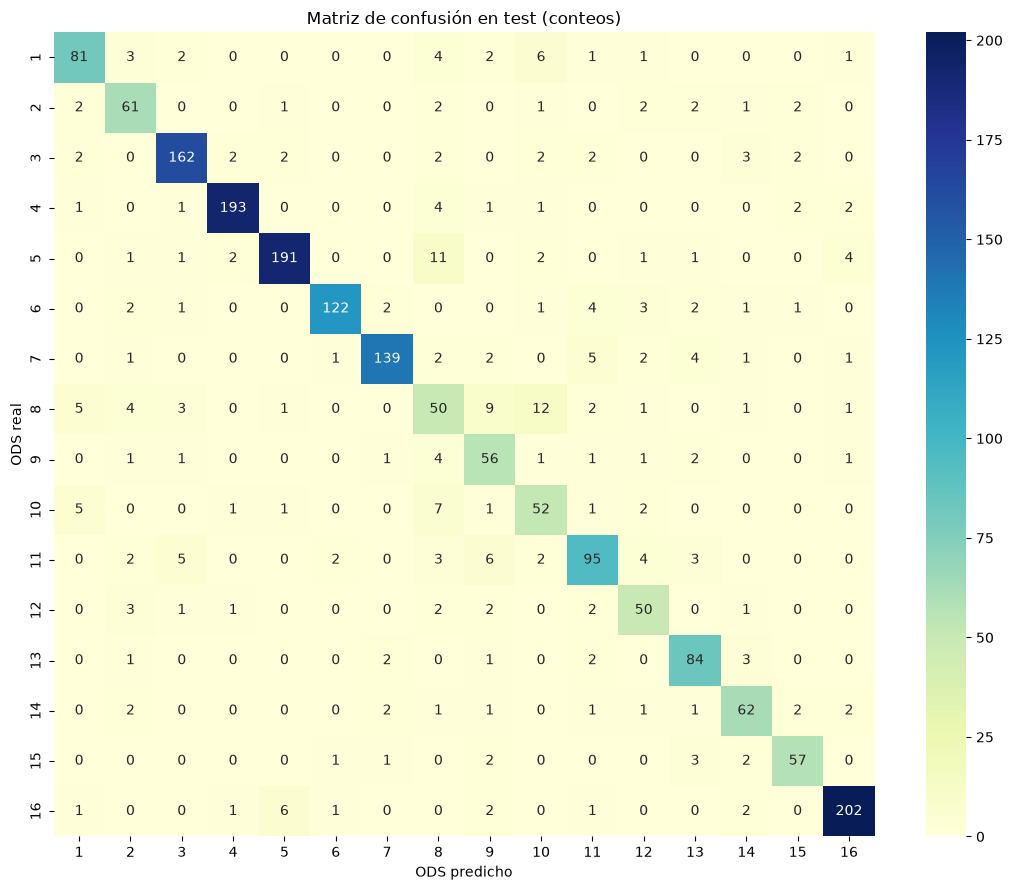

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score,
)

modelo_final = busqueda.best_estimator_
y_pred = modelo_final.predict(X_test)
etiquetas = sorted(y_train.unique())
print('Métricas en test reservado:')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision macro: {precision_score(y_test, y_pred, average="macro", zero_division=0):.3f}')
print(f'Recall macro: {recall_score(y_test, y_pred, average="macro", zero_division=0):.3f}')
print(f'F1 macro: {f1_score(y_test, y_pred, average="macro", zero_division=0):.3f}')
print(f'F1 weighted: {f1_score(y_test, y_pred, average="weighted", zero_division=0):.3f}')
print('Reporte por clase:')
print(classification_report(y_test, y_pred, labels=etiquetas,
                            target_names=[f'ODS {ods}' for ods in etiquetas],
                            zero_division=0))
matriz_confusion = confusion_matrix(y_test, y_pred, labels=etiquetas)
matriz_errores = matriz_confusion.copy()
np.fill_diagonal(matriz_errores, 0)
pares_errores = sorted(
    ((matriz_errores[i, j], etiquetas[i], etiquetas[j])
     for i in range(len(etiquetas)) for j in range(len(etiquetas)) if i != j),
    reverse=True,
)[:8]
print('Confusiones más frecuentes (casos, real, predicho):', pares_errores)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
ax.set(title='Matriz de confusión en test (conteos)', xlabel='ODS predicho', ylabel='ODS real')
plt.tight_layout()
plt.show()

**Lectura de la evaluación.** En los 1.932 textos reservados, el modelo logra accuracy 0,858 y macro-F1 0,827, cercano al 0,822 medio de validación. El F1 ponderado (0,860) supera al macro-F1: el buen desempeño de clases numerosas favorece la media ponderada, mientras el promedio por clase revela mejor las dificultades. ODS 4 alcanza F1 0,95 y ODS 16 F1 0,94; ODS 8 baja a F1 0,55 y ODS 10 a 0,69. En la matriz, la confusión más frecuente es ODS 8 clasificado como ODS 10 (12 textos), seguida de ODS 5 como ODS 8 (11). Estas cifras señalan solapamientos temáticos posibles, pero no prueban por sí solas la causa de cada error.

## 11. Evidencia de clasificación en textos no vistos

Se muestran cuatro predicciones procedentes exclusivamente de `X_test`: dos aciertos y dos errores, con clases reales distintas cuando sea posible. Los fragmentos se recortan a 180 caracteres solo para que la tabla sea legible. Esta selección ilustra comportamientos del modelo y no sustituye las métricas calculadas sobre todo el test.

In [10]:
predicciones_test = pd.DataFrame({
    'texto': X_test, 'ods_real': y_test, 'ods_predicho': y_pred,
})
predicciones_test['resultado'] = np.where(
    predicciones_test['ods_real'].eq(predicciones_test['ods_predicho']),
    'acierto', 'error',
)
aciertos = predicciones_test[predicciones_test['resultado'].eq('acierto')]
errores = predicciones_test[predicciones_test['resultado'].eq('error')]
ejemplos_test = pd.concat([
    aciertos.drop_duplicates('ods_real').head(2),
    errores.drop_duplicates('ods_real').head(2),
])
assert len(ejemplos_test) >= 4
ejemplos_test = ejemplos_test.assign(
    fragmento=ejemplos_test['texto'].str.replace('\n', ' ', regex=False).str.slice(0, 180),
)
print(ejemplos_test[['fragmento', 'ods_real', 'ods_predicho', 'resultado']].to_string())

                                                                                                                                                                                 fragmento  ods_real  ods_predicho resultado
5100  En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como mediadoras principales. Maximizar los beneficios de la parti         5             5   acierto
4959  La seguridad alimentaria se menciona solo una vez, aunque se reconoce la protección de las personas en el sector rural (por ejemplo, la necesidad de proteger a los hogares contra l         2             2   acierto
9248  Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización de residuos en Chile fue de aproximadamente 10% en 2009 (CO        11            12     error
4619  Los patrones detectados fueron diferentes para cada país, al igual que los relacionados con las tareas domésti

**Lectura de los cuatro ejemplos.** El modelo acierta un texto etiquetado ODS 5 sobre la participación de mujeres en procesos de paz y otro ODS 2 sobre seguridad alimentaria. Entre los errores, un texto real ODS 11 sobre reciclaje se predice como ODS 12; ambos objetivos pueden compartir vocabulario sobre residuos. Otro texto real ODS 5 sobre tareas domésticas y cuidado se predice como ODS 4, probablemente influido por la mención de educación en el fragmento. Son explicaciones plausibles a partir de los fragmentos visibles, no diagnósticos causales ni una estimación adicional de rendimiento.

## 12. Conclusiones y limitaciones

El flujo TF-IDF + SVD + normalización + regresión logística permitió clasificar textos en español entre los ODS 1 a 16 presentes en el archivo entregado. La selección de hiperparámetros se hizo con tres pliegues estratificados sobre entrenamiento y macro-F1 como criterio principal; el mejor candidato usó 200 componentes SVD y `C=1`, con macro-F1 medio de 0,822. En los 1.932 textos de test reservados obtuvo accuracy 0,858, precisión macro 0,822, recall macro 0,835, macro-F1 0,827 y F1 ponderado 0,860. Los cuatro ejemplos de test incluyen dos aciertos y dos errores; son ilustrativos y no sustituyen la evaluación completa.

El LSA exploratorio de 12 componentes, ajustado solo con entrenamiento, permitió interpretar direcciones relacionadas con género, derechos, pobreza, salud, agua y clima. Estas direcciones mezclan vocabulario y no equivalen a clases ODS; juntas explican 3,6% de la varianza de TF-IDF. En clasificación, las clases ODS 4 y 16 tuvieron F1 de 0,95 y 0,94, mientras ODS 8 y 10 quedaron en 0,55 y 0,69. La confusión más frecuente fue ODS 8 predicho como ODS 10 (12 textos), lo que señala un punto concreto para analizar en profundidad.

El alcance se limita a las 16 etiquetas observadas: el modelo no puede predecir ODS 17. El enunciado indica que los textos fueron traducidos y aumentados, por lo que el desempeño en documentos originales, otros dominios o nuevos estilos de redacción todavía no está demostrado. La auditoría descartó duplicados exactos, pero no textos casi idénticos ni posibles efectos de la aumentación. Como siguientes pasos, conviene revisar manualmente errores de ODS 8 y 10, estudiar similitudes cercanas entre textos, contrastar otras configuraciones de representación y regularización mediante validación solo en entrenamiento y evaluar un conjunto externo independiente. Incorporar ODS 17 requeriría ejemplos etiquetados de esa clase y una nueva evaluación.